# SPMS LSTM Autoencoder Experimental Report

This notebook is the GitHub-facing experimental report for the Secure Predictive Maintenance System (SPMS) capstone. It rebuilds the aligned LSTM Autoencoder workflow from `Data/data/master_data.csv`, keeps the real 1-minute timestamp grid, and reports anomaly detection results for PMA Granulator monitoring at PT. Saka Farma Laboratories.

Scope boundary: this model is for predictive monitoring only. It does not control, stop, override, or interfere with the PMA Granulator machine.

Important interpretation: this is unsupervised anomaly detection from normal active-running behavior. It is not validated failure prediction, and it is not Remaining Useful Life (RUL), because this dataset does not contain confirmed failure, maintenance, replacement, or degradation labels.


## 1. Setup

The notebook uses deterministic seeds where possible and sets `TF_USE_LEGACY_KERAS=1` before importing TensorFlow. That keeps this Windows environment away from the Keras 3 / OpenCV / NumPy import path that can break notebook execution.


In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)

BASE_DIR = Path.cwd()
if BASE_DIR.name.lower() != "data":
    BASE_DIR = BASE_DIR / "Data"
PROJECT_ROOT = BASE_DIR.parent


def repo_relative(path: Path) -> str:
    try:
        return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


RAW_DATA_PATH = BASE_DIR / "data" / "master_data.csv"
CLEAN_GRID_PATH = BASE_DIR / "data" / "spms_cleaned_full_grid.csv"
WINDOW_METADATA_PATH = BASE_DIR / "data" / "spms_valid_windows_metadata.csv"
WINDOW_TENSOR_PATH = BASE_DIR / "data" / "spms_lstm_windows_rebuild.npz"

EXPORT_DIR = BASE_DIR / "export_models"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = EXPORT_DIR / "spms_lstm_autoencoder_rebuild.keras"
SCALER_PATH = EXPORT_DIR / "spms_minmax_scaler_rebuild.pkl"
THRESHOLD_PATH = EXPORT_DIR / "anomaly_threshold_rebuild.joblib"
METADATA_PATH = EXPORT_DIR / "spms_lstm_rebuild_metadata.json"

TIMESTAMP_COL = "Timeline (Minute)"
BATCH_COL = "batch_id_clean"
PROCESS_COL = "process_id_clean"
WINDOW_SIZE = 15
MICRO_GAP_LIMIT = 2
REQUIRE_SAME_BATCH = True
REQUIRE_SAME_PROCESS = True
RANDOM_SEED = 42

CORE_FEATURES = [
    "impeller_rpm",
    "chopper_rpm",
    "impeller_ampere",
    "X-Axis RMS Velocity (mm/s)",
    "Z-Axis RMS Velocity (mm/s)",
    "X-Axis Peak Acceleration (G)",
    "Z-Axis Peak Acceleration (G)",
    "Temperature C",
]

EXCLUDED_DUPLICATE_FEATURES = [
    "X-Axis RMS Velocity (in/s)",
    "Z-Axis RMS Velocity (in/s)",
]

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print(f"Raw data path: {repo_relative(RAW_DATA_PATH)}")
print(f"TensorFlow version: {tf.__version__}")


Raw data path: Data/data/master_data.csv
TensorFlow version: 2.18.0


## 2. Dataset Overview

The rebuild starts from `master_data.csv`, checks that the raw file is already a complete 1-minute grid, and audits missing and zero values before any model window is created.


,metric,value
0,observed_rows,414720
1,expected_1min_rows,414720
2,timestamp_min,2025-05-30 00:00:00
3,timestamp_max,2026-03-13 23:59:00
4,timestamp_nulls,0
5,duplicate_timestamps,0
6,raw_grid_is_strict_1min,True


,feature,missing_count,missing_rate,zero_count,zero_rate
0,impeller_rpm,52301,0.126112,300398,0.724339
1,chopper_rpm,52301,0.126112,321721,0.775755
2,impeller_ampere,52301,0.126112,296214,0.714251
3,X-Axis RMS Velocity (mm/s),1245,0.003002,0,0.000000
4,Z-Axis RMS Velocity (mm/s),1245,0.003002,0,0.000000
5,X-Axis Peak Acceleration (G),1245,0.003002,0,0.000000
6,Z-Axis Peak Acceleration (G),1245,0.003002,0,0.000000
7,Temperature C,1245,0.003002,0,0.000000


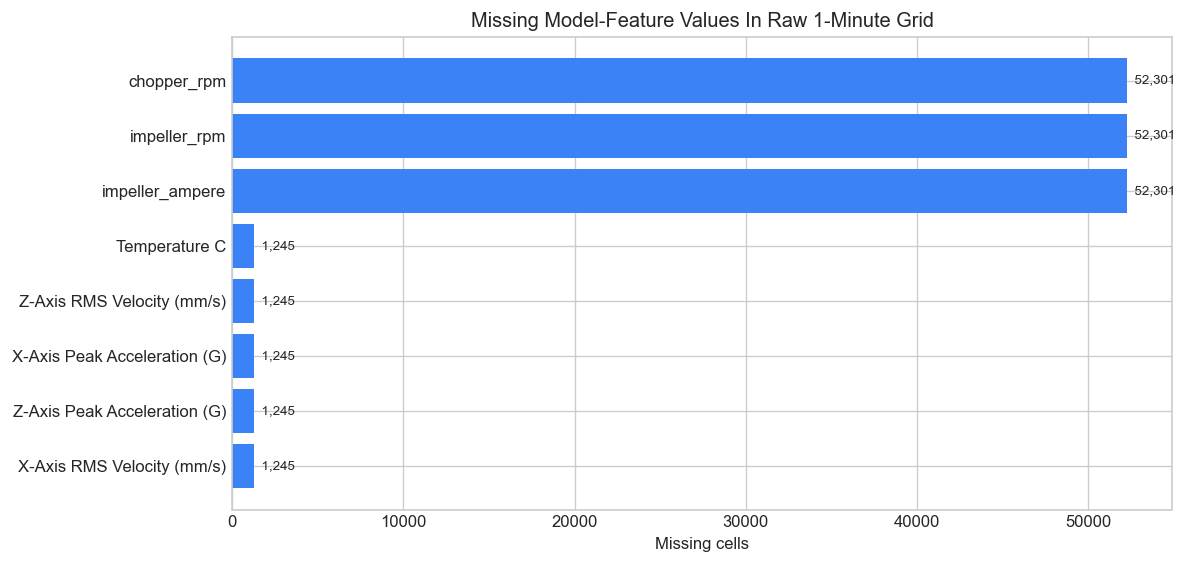

In [2]:
raw = pd.read_csv(RAW_DATA_PATH)
raw["source_row_index"] = np.arange(len(raw), dtype=int)
raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], errors="coerce")
raw = raw.sort_values(TIMESTAMP_COL).reset_index(drop=True)

missing_required = [col for col in [TIMESTAMP_COL, BATCH_COL, PROCESS_COL, *CORE_FEATURES] if col not in raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

duplicate_timestamps = int(raw[TIMESTAMP_COL].duplicated().sum())
timestamp_nulls = int(raw[TIMESTAMP_COL].isna().sum())
min_ts = raw[TIMESTAMP_COL].min()
max_ts = raw[TIMESTAMP_COL].max()
expected_rows = int(((max_ts - min_ts) / pd.Timedelta(minutes=1)) + 1)
observed_rows = len(raw)
one_minute_steps = raw[TIMESTAMP_COL].diff().dropna().eq(pd.Timedelta(minutes=1)).all()

audit_summary = pd.DataFrame(
    [
        ("observed_rows", observed_rows),
        ("expected_1min_rows", expected_rows),
        ("timestamp_min", min_ts),
        ("timestamp_max", max_ts),
        ("timestamp_nulls", timestamp_nulls),
        ("duplicate_timestamps", duplicate_timestamps),
        ("raw_grid_is_strict_1min", bool(one_minute_steps and observed_rows == expected_rows and duplicate_timestamps == 0)),
    ],
    columns=["metric", "value"],
)

missing_zero_report = []
for col in CORE_FEATURES:
    series = pd.to_numeric(raw[col], errors="coerce")
    missing_zero_report.append(
        {
            "feature": col,
            "missing_count": int(series.isna().sum()),
            "missing_rate": float(series.isna().mean()),
            "zero_count": int(series.eq(0).sum()),
            "zero_rate": float(series.eq(0).mean()),
        }
    )

data_quality_report = pd.DataFrame(missing_zero_report)
display(audit_summary)
display(data_quality_report)

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_data = data_quality_report.sort_values("missing_count", ascending=True)
ax.barh(plot_data["feature"], plot_data["missing_count"], color="#3B82F6")
ax.set_title("Missing Model-Feature Values In Raw 1-Minute Grid")
ax.set_xlabel("Missing cells")
ax.set_ylabel("")
for value, label in zip(plot_data["missing_count"], plot_data["feature"]):
    ax.text(value, label, f"  {value:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

assert observed_rows == 414_720, f"Expected 414,720 rows, got {observed_rows:,}"
assert expected_rows == observed_rows, "Raw data does not cover a complete 1-minute grid."
assert duplicate_timestamps == 0, "Raw data contains duplicate timestamps."


## 3. Feature Policy

The model uses eight sensor features. Batch and process identifiers are kept for window validation and traceability, but they are not used as numeric model inputs.


In [3]:
feature_policy = pd.DataFrame(
    [{"feature": feature, "role": "model input"} for feature in CORE_FEATURES]
    + [{"feature": feature, "role": "excluded duplicate unit"} for feature in EXCLUDED_DUPLICATE_FEATURES if feature in raw.columns]
    + [{"feature": BATCH_COL, "role": "window validation only"}, {"feature": PROCESS_COL, "role": "window validation only"}]
)
display(feature_policy)


,feature,role
0,impeller_rpm,model input
1,chopper_rpm,model input
2,impeller_ampere,model input
3,X-Axis RMS Velocity (mm/s),model input
4,Z-Axis RMS Velocity (mm/s),model input
5,X-Axis Peak Acceleration (G),model input
6,Z-Axis Peak Acceleration (G),model input
7,Temperature C,model input
8,X-Axis RMS Velocity (in/s),excluded duplicate unit
9,Z-Axis RMS Velocity (in/s),excluded duplicate unit


## 4. Machine-State Detection

The model is trained only on active-running windows. Offline and transition/idle rows remain in the full grid, but they are rejected during LSTM window generation.


,machine_state,rows,rate
0,Absolute Offline,296128,0.714043
1,Transition/Idle,63043,0.152013
2,Active Running,55549,0.133943


Active rpm floor: 1.0000
Active ampere floor: 12.4800


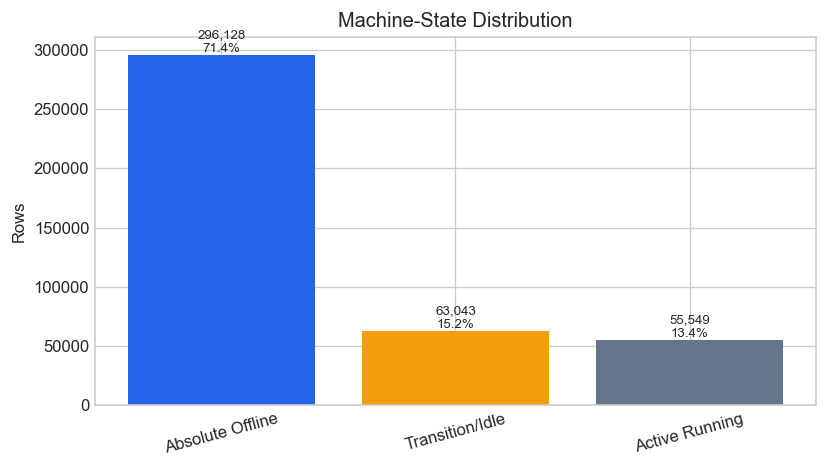

,rows,active_rows,active_rate
process_id_clean,,,
Input Material,197164,41412,0.210038
Mixing II Dry Mixing II,11621,3867,0.332760
discharge 9,60781,3645,0.059969
Mixing III Add Solution,5456,1499,0.274743
Mixing I - Dry Mixing,3756,1258,0.334931
Mixing IV - Granulation,13719,1238,0.090240
Discharge 1,7616,551,0.072348
Discharge 12,35254,483,0.013701
discharge 6,13984,382,0.027317


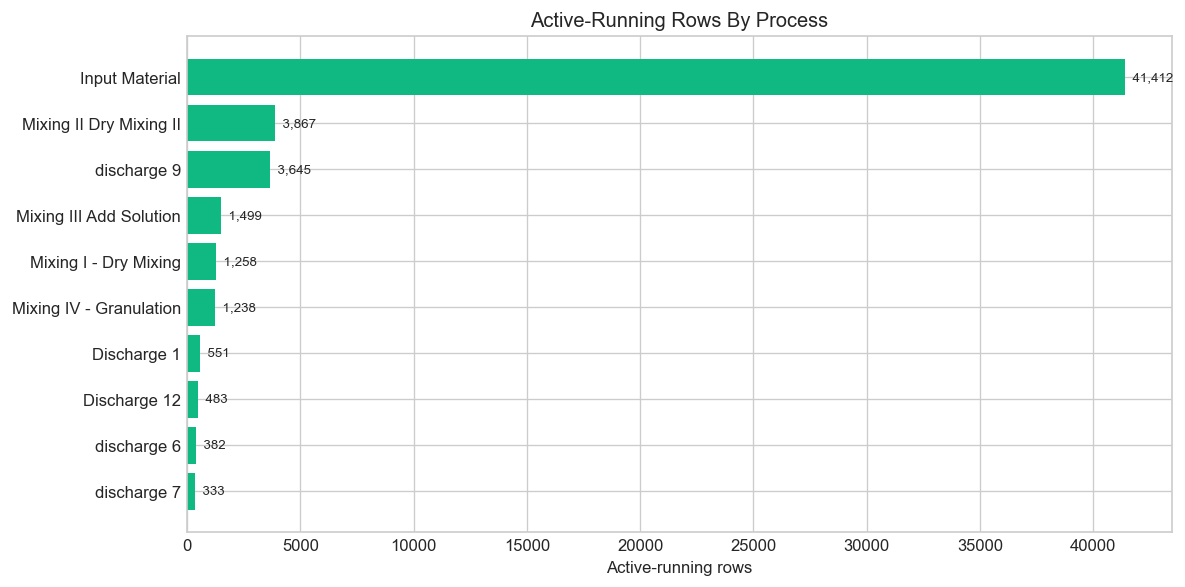

,rows,active_rows,chopper_on_rows,active_chopper_on_rows,active_chopper_on_rate
process_id_clean,,,,,
Input Material,197164,41412,26717,22000,0.531247
Mixing II Dry Mixing II,11621,3867,4353,3627,0.937936
discharge 9,60781,3645,2957,2624,0.719890
Mixing III Add Solution,5456,1499,1593,1336,0.891261
Mixing I - Dry Mixing,3756,1258,1347,1110,0.882353
Mixing IV - Granulation,13719,1238,1362,1121,0.905493
Discharge 1,7616,551,614,487,0.883848
Discharge 12,35254,483,224,181,0.374741
discharge 6,13984,382,332,264,0.691099


In [4]:
df = raw.copy()
for col in CORE_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

absolute_offline = df["impeller_rpm"].eq(0) & df["impeller_ampere"].eq(0)

nonzero_rpm = df.loc[df["impeller_rpm"] > 0, "impeller_rpm"]
nonzero_amp = df.loc[df["impeller_ampere"] > 0, "impeller_ampere"]
rpm_active_floor = float(max(1.0, nonzero_rpm.quantile(0.05))) if len(nonzero_rpm) else 1.0
amp_active_floor = float(max(0.05, nonzero_amp.quantile(0.05))) if len(nonzero_amp) else 0.05

active_running = (
    df["impeller_rpm"].ge(rpm_active_floor)
    & df["impeller_ampere"].ge(amp_active_floor)
    & df[["impeller_rpm", "impeller_ampere"]].notna().all(axis=1)
)

df["machine_state"] = np.select(
    [absolute_offline, active_running],
    ["Absolute Offline", "Active Running"],
    default="Transition/Idle",
)

state_counts = df["machine_state"].value_counts(dropna=False).rename_axis("machine_state").reset_index(name="rows")
state_counts["rate"] = state_counts["rows"] / len(df)
display(state_counts)
print(f"Active rpm floor: {rpm_active_floor:.4f}")
print(f"Active ampere floor: {amp_active_floor:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(state_counts["machine_state"], state_counts["rows"], color=["#2563EB", "#F59E0B", "#64748B"])
ax.set_title("Machine-State Distribution")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=15)
for idx, row in state_counts.iterrows():
    ax.text(idx, row["rows"], f"{row['rows']:,}\n{row['rate']:.1%}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

active_by_process = (
    df.assign(is_active=df["machine_state"].eq("Active Running"))
    .groupby(PROCESS_COL, dropna=False)
    .agg(rows=(PROCESS_COL, "size"), active_rows=("is_active", "sum"), active_rate=("is_active", "mean"))
    .sort_values("active_rows", ascending=False)
)
display(active_by_process.head(20))

top_active_processes = active_by_process.head(10).sort_values("active_rows")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_active_processes.index.astype(str), top_active_processes["active_rows"], color="#10B981")
ax.set_title("Active-Running Rows By Process")
ax.set_xlabel("Active-running rows")
ax.set_ylabel("")
for value, label in zip(top_active_processes["active_rows"], top_active_processes.index.astype(str)):
    ax.text(value, label, f"  {value:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

active_chopper_source = df.assign(
    is_active=df["machine_state"].eq("Active Running"),
    chopper_on=df["chopper_rpm"].gt(0),
)
active_chopper_diagnostic = (
    active_chopper_source
    .groupby(PROCESS_COL, dropna=False)
    .agg(rows=(PROCESS_COL, "size"), active_rows=("is_active", "sum"), chopper_on_rows=("chopper_on", "sum"))
    .sort_values("active_rows", ascending=False)
)
active_chopper_on_rows = (
    active_chopper_source.loc[active_chopper_source["is_active"] & active_chopper_source["chopper_on"]]
    .groupby(PROCESS_COL, dropna=False)
    .size()
)
active_chopper_diagnostic["active_chopper_on_rows"] = (
    active_chopper_on_rows.reindex(active_chopper_diagnostic.index, fill_value=0).astype(int)
)
active_chopper_diagnostic["active_chopper_on_rate"] = active_chopper_diagnostic["active_chopper_on_rows"] / active_chopper_diagnostic["active_rows"].replace(0, np.nan)
display(active_chopper_diagnostic.head(20))


## 5. Gap Protocol

The full 1-minute grid is preserved. Micro-gaps up to 2 minutes are linearly interpolated. Macro-gaps stay as `NaN`, and any LSTM window touching those `NaN` values is rejected.


,feature,missing_before,missing_after,micro_gap_values_interpolated,macro_gap_values_preserved
0,impeller_rpm,52301,49268,3033,49268
1,chopper_rpm,52301,49268,3033,49268
2,impeller_ampere,52301,49268,3033,49268
3,X-Axis RMS Velocity (mm/s),1245,1008,237,1008
4,Z-Axis RMS Velocity (mm/s),1245,1008,237,1008
5,X-Axis Peak Acceleration (G),1245,1008,237,1008
6,Z-Axis Peak Acceleration (G),1245,1008,237,1008
7,Temperature C,1245,1008,237,1008


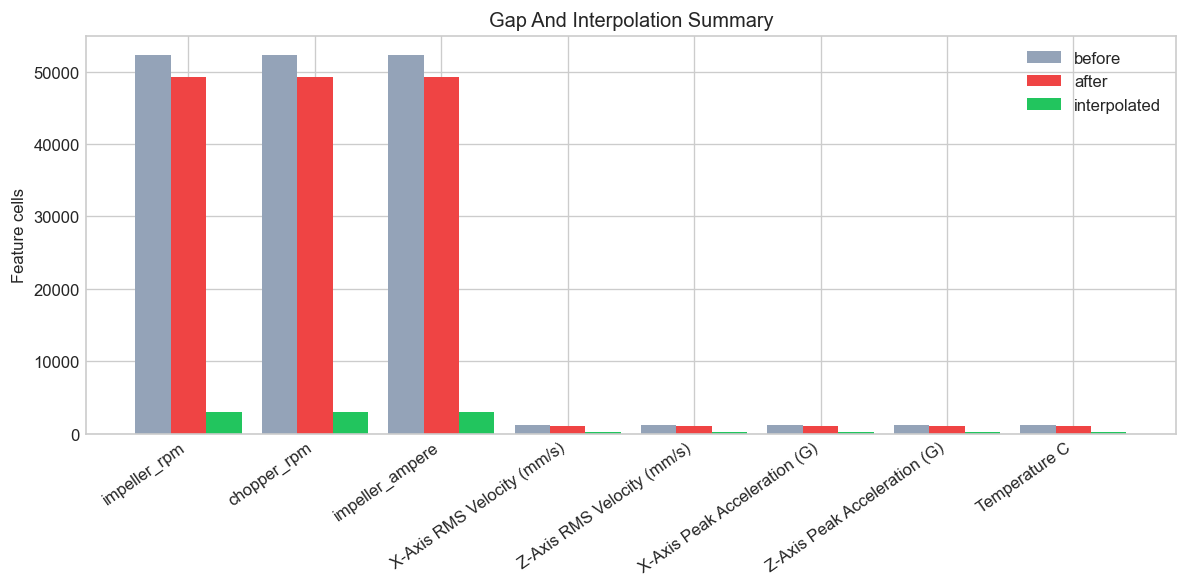

Full-grid rows: 414,720
Rows with remaining model-feature NaN after micro-gap interpolation: 50,219
Remaining missing model-feature cells after interpolation: 152,844
Missing model-feature cells filled as eligible micro-gaps: 10,284


In [5]:
def interpolate_micro_gaps_only(series: pd.Series, limit: int = 2) -> pd.Series:
    missing = series.isna()
    if not missing.any():
        return series
    run_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    eligible_micro_gap = missing & run_length.le(limit)
    interpolated = series.interpolate(method="time", limit_area="inside")
    return series.where(~eligible_micro_gap, interpolated)


full_index = pd.date_range(min_ts, max_ts, freq="min", name=TIMESTAMP_COL)
df_grid = df.set_index(TIMESTAMP_COL).reindex(full_index)

for col in CORE_FEATURES:
    df_grid[col] = pd.to_numeric(df_grid[col], errors="coerce")

pre_missing = df_grid[CORE_FEATURES].isna()
macro_gap_masks = {}
for col in CORE_FEATURES:
    missing = pre_missing[col]
    run_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    macro_gap_masks[col] = missing & run_length.gt(MICRO_GAP_LIMIT)

for col in CORE_FEATURES:
    df_grid[col] = interpolate_micro_gaps_only(df_grid[col], limit=MICRO_GAP_LIMIT)
post_missing = df_grid[CORE_FEATURES].isna()

for col, macro_gap_mask in macro_gap_masks.items():
    if not df_grid.loc[macro_gap_mask, col].isna().all():
        raise AssertionError(f"Macro-gap cells were filled for {col}")

interpolation_report = pd.DataFrame(
    {
        "feature": CORE_FEATURES,
        "missing_before": [int(pre_missing[col].sum()) for col in CORE_FEATURES],
        "missing_after": [int(post_missing[col].sum()) for col in CORE_FEATURES],
        "micro_gap_values_interpolated": [int(pre_missing[col].sum() - post_missing[col].sum()) for col in CORE_FEATURES],
        "macro_gap_values_preserved": [int(macro_gap_masks[col].sum()) for col in CORE_FEATURES],
    }
)
display(interpolation_report)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(interpolation_report))
width = 0.28
ax.bar(x - width, interpolation_report["missing_before"], width, label="before", color="#94A3B8")
ax.bar(x, interpolation_report["missing_after"], width, label="after", color="#EF4444")
ax.bar(x + width, interpolation_report["micro_gap_values_interpolated"], width, label="interpolated", color="#22C55E")
ax.set_title("Gap And Interpolation Summary")
ax.set_ylabel("Feature cells")
ax.set_xticks(x)
ax.set_xticklabels(interpolation_report["feature"], rotation=35, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

df_grid["has_model_feature_nan"] = df_grid[CORE_FEATURES].isna().any(axis=1)
df_grid["macro_gap_row"] = df_grid["has_model_feature_nan"]
df_grid["active_running"] = df_grid["machine_state"].eq("Active Running")

macro_gap_cells_remaining_nan = int(post_missing.sum().sum())
micro_gap_cells_interpolated = int(pre_missing.sum().sum() - post_missing.sum().sum())
print(f"Full-grid rows: {len(df_grid):,}")
print(f"Rows with remaining model-feature NaN after micro-gap interpolation: {int(df_grid['has_model_feature_nan'].sum()):,}")
print(f"Remaining missing model-feature cells after interpolation: {macro_gap_cells_remaining_nan:,}")
print(f"Missing model-feature cells filled as eligible micro-gaps: {micro_gap_cells_interpolated:,}")
assert df_grid.loc[df_grid["macro_gap_row"], CORE_FEATURES].isna().any(axis=1).all()


## 6. Valid 15-Minute Window Generation

LSTM windows are generated from the full timestamp grid. A valid window must contain 15 continuous minutes, no missing model features, active-running state for every row, one batch, and one process.


,windows
feature_nan,51852
not_active_all_rows,357448
cross_batch_or_missing_batch,2
cross_process_or_missing_process,427


,window_id,start_timestamp,end_timestamp,grid_start_pos,grid_end_pos,batch_id,process_id,same_process,source_row_indexes
0,0,2025-05-30 21:26:00,2025-05-30 21:40:00,1286,1300,STMXGE53660-20,Input Material,True,"[1286, 1287, 1288, 1289, 1290, 1291, 1292, 129..."
1,1,2025-05-30 21:27:00,2025-05-30 21:41:00,1287,1301,STMXGE53660-20,Input Material,True,"[1287, 1288, 1289, 1290, 1291, 1292, 1293, 129..."
2,2,2025-05-30 21:28:00,2025-05-30 21:42:00,1288,1302,STMXGE53660-20,Input Material,True,"[1288, 1289, 1290, 1291, 1292, 1293, 1294, 129..."
3,3,2025-05-30 21:29:00,2025-05-30 21:43:00,1289,1303,STMXGE53660-20,Input Material,True,"[1289, 1290, 1291, 1292, 1293, 1294, 1295, 129..."
4,4,2025-05-30 21:30:00,2025-05-30 21:44:00,1290,1304,STMXGE53660-20,Input Material,True,"[1290, 1291, 1292, 1293, 1294, 1295, 1296, 129..."


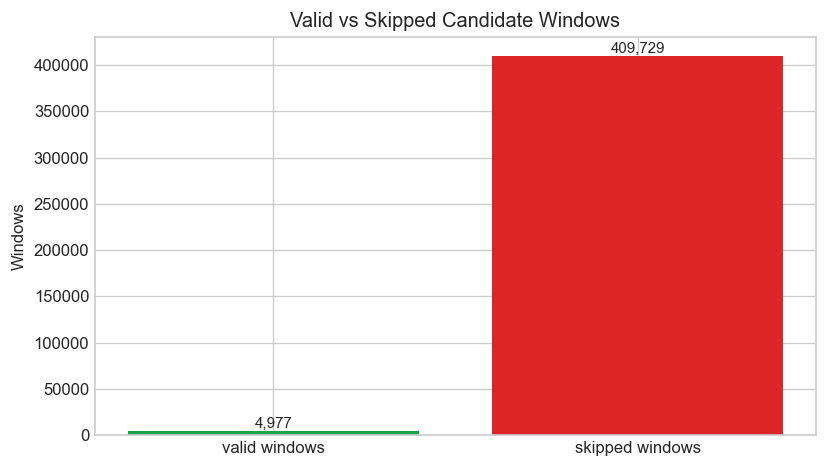

Valid windows before split embargo: 4,977
Skipped windows: 409,729
Process-crossing windows retained: 0
Valid windows containing at least one chopper_rpm == 0 row: 4,710


In [6]:
def same_non_null(values: np.ndarray) -> bool:
    if pd.isna(values).any():
        return False
    return len(pd.unique(values)) == 1


feature_values = df_grid[CORE_FEATURES].to_numpy(dtype=np.float32)
timestamps = df_grid.index.to_numpy()
active_flags = df_grid["active_running"].fillna(False).to_numpy(dtype=bool)
batch_values = df_grid[BATCH_COL].to_numpy()
process_values = df_grid[PROCESS_COL].to_numpy()
source_row_indexes = df_grid["source_row_index"].to_numpy()

valid_windows = []
skipped = {
    "feature_nan": 0,
    "not_active_all_rows": 0,
    "cross_batch_or_missing_batch": 0,
    "cross_process_or_missing_process": 0,
}

for start in range(0, len(df_grid) - WINDOW_SIZE + 1):
    end = start + WINDOW_SIZE
    window = feature_values[start:end]

    if np.isnan(window).any():
        skipped["feature_nan"] += 1
        continue
    if not active_flags[start:end].all():
        skipped["not_active_all_rows"] += 1
        continue
    if REQUIRE_SAME_BATCH and not same_non_null(batch_values[start:end]):
        skipped["cross_batch_or_missing_batch"] += 1
        continue
    if REQUIRE_SAME_PROCESS and not same_non_null(process_values[start:end]):
        skipped["cross_process_or_missing_process"] += 1
        continue

    source_idx = [None if pd.isna(value) else int(value) for value in source_row_indexes[start:end]]
    valid_windows.append(
        {
            "window_id": len(valid_windows),
            "start_timestamp": pd.Timestamp(timestamps[start]),
            "end_timestamp": pd.Timestamp(timestamps[end - 1]),
            "grid_start_pos": start,
            "grid_end_pos": end - 1,
            "batch_id": batch_values[start],
            "process_id": process_values[start],
            "same_process": same_non_null(process_values[start:end]),
            "source_row_indexes": json.dumps(source_idx),
        }
    )

windows_metadata = pd.DataFrame(valid_windows)
windows_before_split_embargo = len(windows_metadata)
skipped_window_count = int(sum(skipped.values()))
display(pd.DataFrame([skipped]).T.rename(columns={0: "windows"}))
display(windows_metadata.head())

if windows_metadata.empty:
    raise RuntimeError("No valid LSTM windows were produced. Review active-state criteria and gap policy.")

windows_with_chopper_zero = 0
for row in windows_metadata.itertuples(index=False):
    window_chopper = df_grid["chopper_rpm"].iloc[row.grid_start_pos : row.grid_end_pos + 1]
    if window_chopper.eq(0).any():
        windows_with_chopper_zero += 1

summary_counts = pd.DataFrame(
    [
        {"category": "valid windows", "windows": windows_before_split_embargo},
        {"category": "skipped windows", "windows": skipped_window_count},
    ]
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary_counts["category"], summary_counts["windows"], color=["#16A34A", "#DC2626"])
ax.set_title("Valid vs Skipped Candidate Windows")
ax.set_ylabel("Windows")
for idx, row in summary_counts.iterrows():
    ax.text(idx, row["windows"], f"{row['windows']:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

sample_meta = windows_metadata.sample(min(1_000, len(windows_metadata)), random_state=RANDOM_SEED)
for row in sample_meta.itertuples():
    idx = df_grid.index[row.grid_start_pos : row.grid_end_pos + 1]
    if not idx.to_series().diff().dropna().eq(pd.Timedelta(minutes=1)).all():
        raise AssertionError(f"Non-continuous retained window: {row.window_id}")
if REQUIRE_SAME_PROCESS and not windows_metadata["same_process"].all():
    raise AssertionError("Process-crossing windows were retained even though REQUIRE_SAME_PROCESS is True")

print(f"Valid windows before split embargo: {windows_before_split_embargo:,}")
print(f"Skipped windows: {skipped_window_count:,}")
print(f"Process-crossing windows retained: {int((~windows_metadata['same_process']).sum()):,}")
print(f"Valid windows containing at least one chopper_rpm == 0 row: {windows_with_chopper_zero:,}")


## 7. Chronological Split And Scaling

Windows are sorted by time, then split into train, validation, and test groups. A split-boundary embargo removes windows that would overlap across split boundaries. The scaler is fit only on train windows.


,windows,first_window_start,first_window_end,last_window_start,last_window_end
split,,,,,
train,3483,2025-05-30 21:26:00,2025-05-30 21:40:00,2025-11-06 22:45:00,2025-11-06 22:59:00
validation,746,2025-11-07 22:32:00,2025-11-07 22:46:00,2026-02-20 14:45:00,2026-02-20 14:59:00
test,734,2026-02-20 15:00:00,2026-02-20 15:14:00,2026-03-13 00:32:00,2026-03-13 00:46:00


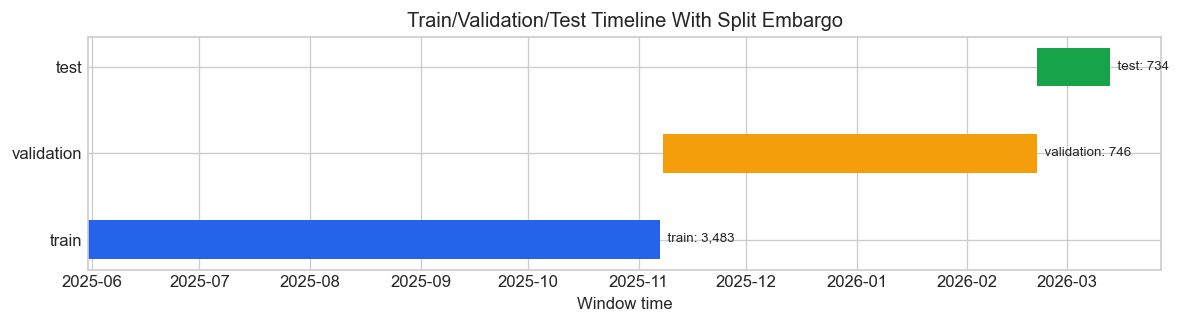

Windows dropped to prevent split-boundary overlap: 14
X_train shape: (3483, 15, 8)
X_val shape: (746, 15, 8)
X_test shape: (734, 15, 8)


In [7]:
windows_metadata = windows_metadata.sort_values("end_timestamp").reset_index(drop=True)
n_windows = len(windows_metadata)
train_target = int(n_windows * 0.70)
val_target = int(n_windows * 0.15)

train_meta = windows_metadata.iloc[:train_target].copy()
train_last_end = train_meta["end_timestamp"].max()
validation_candidates = windows_metadata.iloc[train_target:].loc[
    lambda frame: frame["start_timestamp"].gt(train_last_end)
]
validation_meta = validation_candidates.iloc[:val_target].copy()
validation_last_end = validation_meta["end_timestamp"].max()
test_meta = windows_metadata.loc[
    windows_metadata["start_timestamp"].gt(validation_last_end)
    & windows_metadata["end_timestamp"].gt(validation_last_end)
].copy()

train_meta["split"] = "train"
validation_meta["split"] = "validation"
test_meta["split"] = "test"
windows_metadata = pd.concat([train_meta, validation_meta, test_meta], ignore_index=True)
windows_dropped_for_split_embargo = windows_before_split_embargo - len(windows_metadata)

split_report = (
    windows_metadata.groupby("split", sort=False)
    .agg(
        windows=("window_id", "count"),
        first_window_start=("start_timestamp", "first"),
        first_window_end=("end_timestamp", "first"),
        last_window_start=("start_timestamp", "last"),
        last_window_end=("end_timestamp", "last"),
    )
)
display(split_report)

ordered_splits = ["train", "validation", "test"]
for left, right in zip(ordered_splits, ordered_splits[1:]):
    left_end = windows_metadata.loc[windows_metadata["split"].eq(left), "end_timestamp"].max()
    right_start = windows_metadata.loc[windows_metadata["split"].eq(right), "start_timestamp"].min()
    if right_start <= left_end:
        raise AssertionError(f"Split leakage: {left} ends at {left_end}, but {right} starts at {right_start}")

fig, ax = plt.subplots(figsize=(10, 2.8))
colors = {"train": "#2563EB", "validation": "#F59E0B", "test": "#16A34A"}
for y, split in enumerate(ordered_splits):
    row = split_report.loc[split]
    start = pd.to_datetime(row["first_window_start"])
    end = pd.to_datetime(row["last_window_end"])
    ax.barh(y, (end - start).total_seconds() / 86400, left=start, color=colors[split], height=0.45, label=split)
    ax.text(end, y, f"  {split}: {int(row['windows']):,}", va="center", fontsize=8)
ax.set_yticks(range(len(ordered_splits)))
ax.set_yticklabels(ordered_splits)
ax.set_title("Train/Validation/Test Timeline With Split Embargo")
ax.set_xlabel("Window time")
plt.tight_layout()
plt.show()

def materialize_windows(meta: pd.DataFrame) -> np.ndarray:
    out = np.empty((len(meta), WINDOW_SIZE, len(CORE_FEATURES)), dtype=np.float32)
    for pos, row in enumerate(meta.itertuples(index=False)):
        out[pos] = feature_values[row.grid_start_pos : row.grid_end_pos + 1]
    return out


X_all = materialize_windows(windows_metadata)
X_train_raw = X_all[windows_metadata["split"].eq("train").to_numpy()]
X_val_raw = X_all[windows_metadata["split"].eq("validation").to_numpy()]
X_test_raw = X_all[windows_metadata["split"].eq("test").to_numpy()]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw.reshape(-1, len(CORE_FEATURES))).reshape(X_train_raw.shape)
X_val = scaler.transform(X_val_raw.reshape(-1, len(CORE_FEATURES))).reshape(X_val_raw.shape)
X_test = scaler.transform(X_test_raw.reshape(-1, len(CORE_FEATURES))).reshape(X_test_raw.shape)

print(f"Windows dropped to prevent split-boundary overlap: {windows_dropped_for_split_embargo:,}")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


## 8. LSTM Autoencoder Training

The model learns to reconstruct normal active-running sensor windows. A higher reconstruction error means the window is less similar to the training pattern.


Model: "spms_lstm_autoencoder_rebuild"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 sensor_window (InputLayer)  [(None, 15, 8)]           0         


 encoder_lstm_64 (LSTM)      (None, 15, 64)            18688     


...

Total params: 64776 (253.03 KB)


Trainable params: 64776 (253.03 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


,loss,val_loss
epoch,,
44,0.033228,0.049953
45,0.033121,0.050992
46,0.032965,0.050944
47,0.032976,0.051134
48,0.032671,0.051582


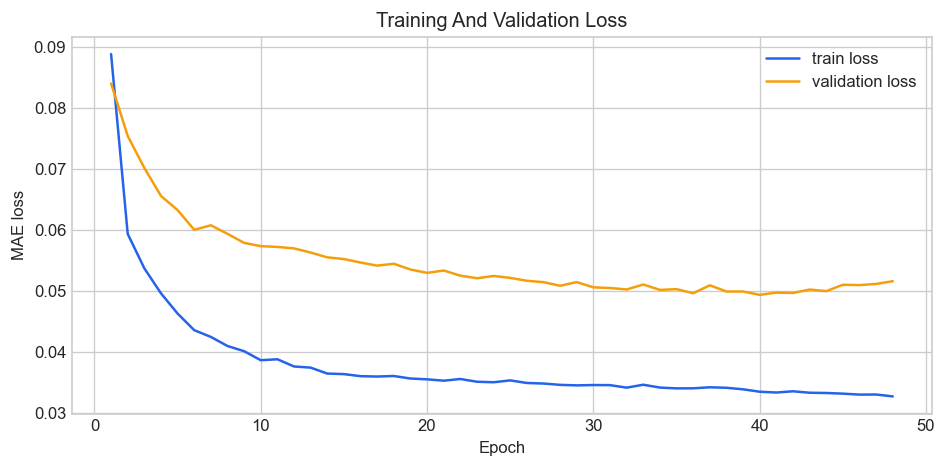

Saved model: Data/export_models/spms_lstm_autoencoder_rebuild.keras
Saved scaler: Data/export_models/spms_minmax_scaler_rebuild.pkl


In [8]:
def build_lstm_autoencoder(window_size: int, n_features: int) -> keras.Model:
    inputs = keras.Input(shape=(window_size, n_features), name="sensor_window")
    x = layers.LSTM(64, return_sequences=True, name="encoder_lstm_64")(inputs)
    x = layers.LSTM(32, return_sequences=False, name="encoder_lstm_32")(x)
    x = layers.RepeatVector(window_size, name="repeat_latent")(x)
    x = layers.LSTM(32, return_sequences=True, name="decoder_lstm_32")(x)
    x = layers.LSTM(64, return_sequences=True, name="decoder_lstm_64")(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features), name="reconstruction")(x)
    model = keras.Model(inputs, outputs, name="spms_lstm_autoencoder_rebuild")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mae")
    return model


model = build_lstm_autoencoder(WINDOW_SIZE, len(CORE_FEATURES))
model.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"
display(history_df.tail())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df.index, history_df["loss"], label="train loss", color="#2563EB")
ax.plot(history_df.index, history_df["val_loss"], label="validation loss", color="#F59E0B")
ax.set_title("Training And Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE loss")
ax.legend()
plt.tight_layout()
plt.show()

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
print(f"Saved model: {repo_relative(MODEL_PATH)}")
print(f"Saved scaler: {repo_relative(SCALER_PATH)}")


## 9. Thresholding

The anomaly threshold is the 99th percentile of validation reconstruction MAE. This keeps threshold selection out of the test set.


In [9]:
def reconstruction_error(model: keras.Model, x: np.ndarray, batch_size: int = 256) -> np.ndarray:
    pred = model.predict(x, batch_size=batch_size, verbose=0)
    return np.mean(np.abs(x - pred), axis=(1, 2))


train_errors = reconstruction_error(model, X_train)
val_errors = reconstruction_error(model, X_val)
test_errors = reconstruction_error(model, X_test)

percentile_levels = [95, 97.5, 99, 99.5]
threshold_table = pd.DataFrame(
    {
        "percentile": percentile_levels,
        "train_error": [np.percentile(train_errors, p) for p in percentile_levels],
        "validation_error": [np.percentile(val_errors, p) for p in percentile_levels],
    }
)
threshold = float(np.percentile(val_errors, 99))
display(threshold_table)
print(f"Selected threshold: {threshold:.12f} (99th percentile of validation reconstruction MAE)")

threshold_metadata = {
    "threshold": threshold,
    "policy": "99th percentile of validation reconstruction MAE",
    "loss": "mae",
    "percentiles": threshold_table.to_dict(orient="records"),
    "features": CORE_FEATURES,
    "window_size": WINDOW_SIZE,
}
joblib.dump(threshold_metadata, THRESHOLD_PATH)
print(f"Saved threshold metadata: {repo_relative(THRESHOLD_PATH)}")


,percentile,train_error,validation_error
0,95.0,0.079463,0.127706
1,97.5,0.089385,0.170233
2,99.0,0.098052,0.224178
3,99.5,0.102098,0.239052


Selected threshold: 0.224177509546 (99th percentile of validation reconstruction MAE)
Saved threshold metadata: Data/export_models/anomaly_threshold_rebuild.joblib


## 10. Evaluation Insights

The outputs below summarize reconstruction error and anomaly concentration. They do not report precision, recall, or RUL validation because the current dataset has no confirmed failure labels.


,split,windows,anomalies,anomaly_rate,mean_error,max_error
0,train,3483,0,0.000000,0.034170,0.130502
1,validation,746,8,0.010724,0.049343,0.252121
2,test,734,45,0.061308,0.118937,0.271724


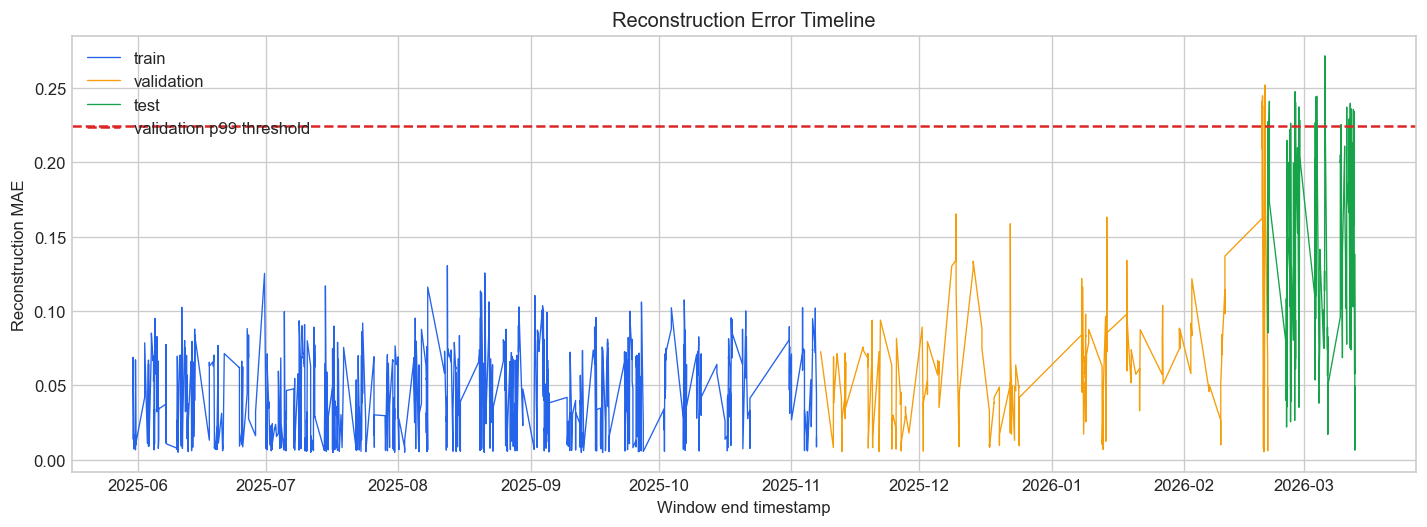

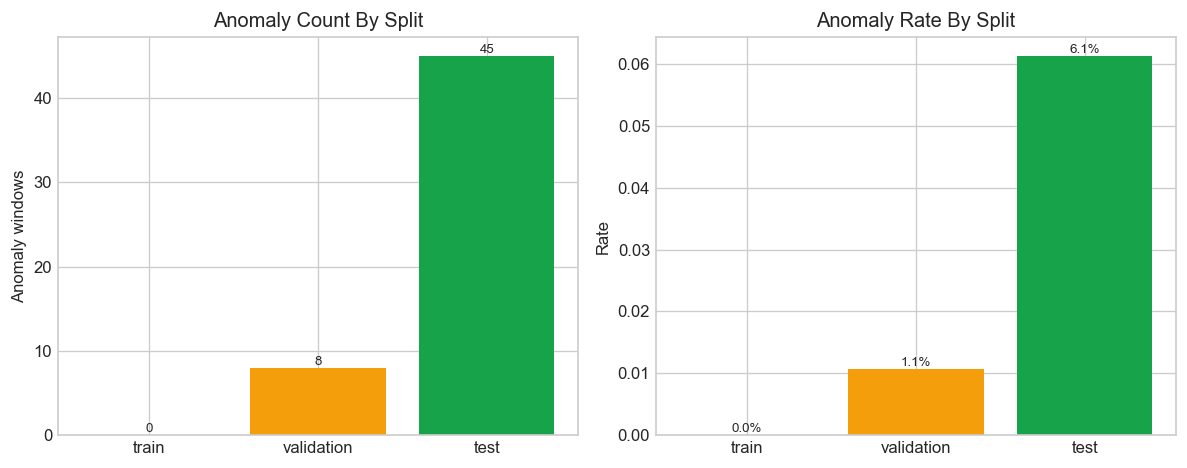

,windows,anomalies,anomaly_rate
month,,,
2025-05,55,0,0.000000
2025-06,497,0,0.000000
2025-07,902,0,0.000000
2025-08,812,0,0.000000
2025-09,760,0,0.000000
2025-10,352,0,0.000000
2025-11,291,0,0.000000
2025-12,251,0,0.000000
2026-01,165,0,0.000000


,windows,anomalies,anomaly_rate
process_id,,,
Input Material,4714,53,0.011243
Discharge 12,20,0,0.000000
Mixing I - Dry Mixing,21,0,0.000000
Mixing II Dry Mixing II,22,0,0.000000
Mixing III Add Solution,2,0,0.000000
Mixing IV - Granulation,29,0,0.000000
VACUUM I,21,0,0.000000
discharge 10,5,0,0.000000
discharge 7,2,0,0.000000


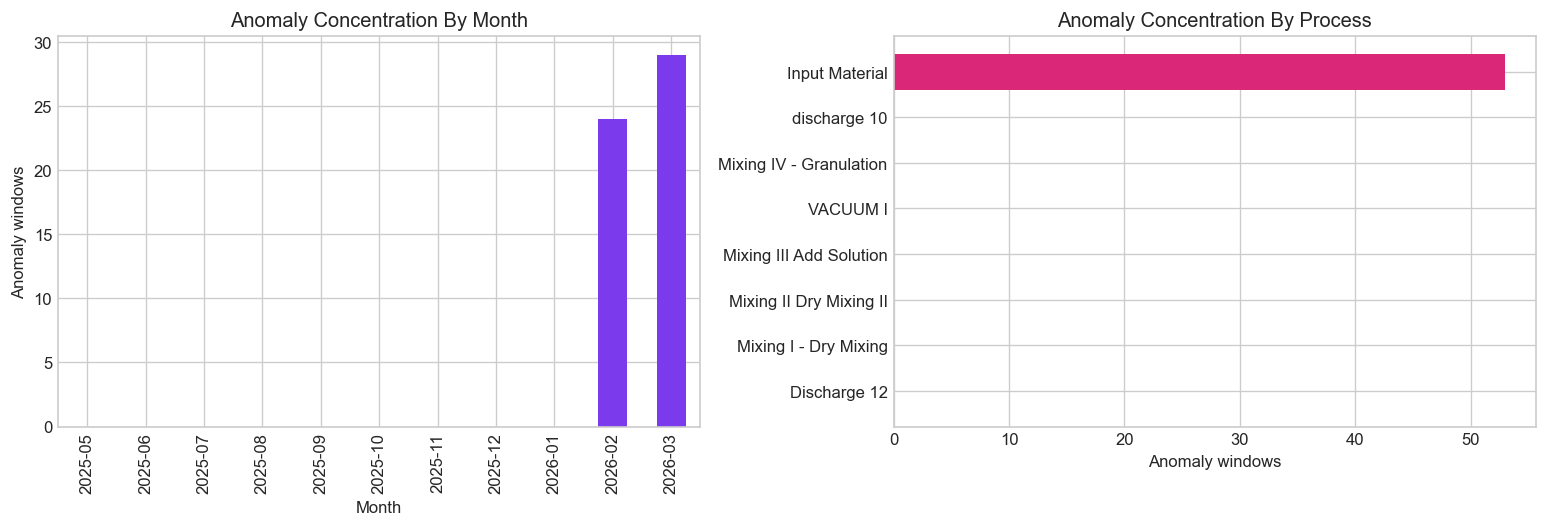

Limitation: this evaluation is unsupervised anomaly detection only. There are no confirmed failure labels, so precision, recall, and RUL validity are not established.


In [10]:
split_errors = {"train": train_errors, "validation": val_errors, "test": test_errors}
evaluation_rows = []
for split, errors in split_errors.items():
    anomaly_flags = errors > threshold
    evaluation_rows.append(
        {
            "split": split,
            "windows": len(errors),
            "anomalies": int(anomaly_flags.sum()),
            "anomaly_rate": float(anomaly_flags.mean()) if len(errors) else np.nan,
            "mean_error": float(np.mean(errors)) if len(errors) else np.nan,
            "max_error": float(np.max(errors)) if len(errors) else np.nan,
        }
    )
evaluation_report = pd.DataFrame(evaluation_rows)
display(evaluation_report)

all_errors = np.concatenate([train_errors, val_errors, test_errors])
windows_metadata["reconstruction_error"] = all_errors
windows_metadata["is_anomaly"] = windows_metadata["reconstruction_error"].gt(threshold)
windows_metadata["month"] = windows_metadata["end_timestamp"].dt.to_period("M").astype(str)

fig, ax = plt.subplots(figsize=(12, 4.5))
for split in ordered_splits:
    subset = windows_metadata[windows_metadata["split"].eq(split)]
    ax.plot(subset["end_timestamp"], subset["reconstruction_error"], linewidth=0.8, label=split, color=colors[split])
ax.axhline(threshold, color="#DC2626", linestyle="--", label="validation p99 threshold")
ax.set_title("Reconstruction Error Timeline")
ax.set_xlabel("Window end timestamp")
ax.set_ylabel("Reconstruction MAE")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(evaluation_report["split"], evaluation_report["anomalies"], color=[colors[s] for s in evaluation_report["split"]])
axes[0].set_title("Anomaly Count By Split")
axes[0].set_ylabel("Anomaly windows")
for idx, row in evaluation_report.iterrows():
    axes[0].text(idx, row["anomalies"], f"{row['anomalies']:,}", ha="center", va="bottom", fontsize=8)
axes[1].bar(evaluation_report["split"], evaluation_report["anomaly_rate"], color=[colors[s] for s in evaluation_report["split"]])
axes[1].set_title("Anomaly Rate By Split")
axes[1].set_ylabel("Rate")
for idx, row in evaluation_report.iterrows():
    axes[1].text(idx, row["anomaly_rate"], f"{row['anomaly_rate']:.1%}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

month_summary = windows_metadata.groupby("month")["is_anomaly"].agg(["count", "sum", "mean"]).rename(columns={"count": "windows", "sum": "anomalies", "mean": "anomaly_rate"})
process_summary = windows_metadata.groupby("process_id")["is_anomaly"].agg(["count", "sum", "mean"]).sort_values("sum", ascending=False).rename(columns={"count": "windows", "sum": "anomalies", "mean": "anomaly_rate"})
display(month_summary)
display(process_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
month_summary["anomalies"].plot(kind="bar", ax=axes[0], color="#7C3AED")
axes[0].set_title("Anomaly Concentration By Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Anomaly windows")
top_process = process_summary.head(8).sort_values("anomalies")
axes[1].barh(top_process.index.astype(str), top_process["anomalies"], color="#DB2777")
axes[1].set_title("Anomaly Concentration By Process")
axes[1].set_xlabel("Anomaly windows")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print("Limitation: this evaluation is unsupervised anomaly detection only. There are no confirmed failure labels, so precision, recall, and RUL validity are not established.")


## 11. Reconstruction Examples

These examples compare the scaled input window against the reconstructed output for one normal test window and one anomalous test window.


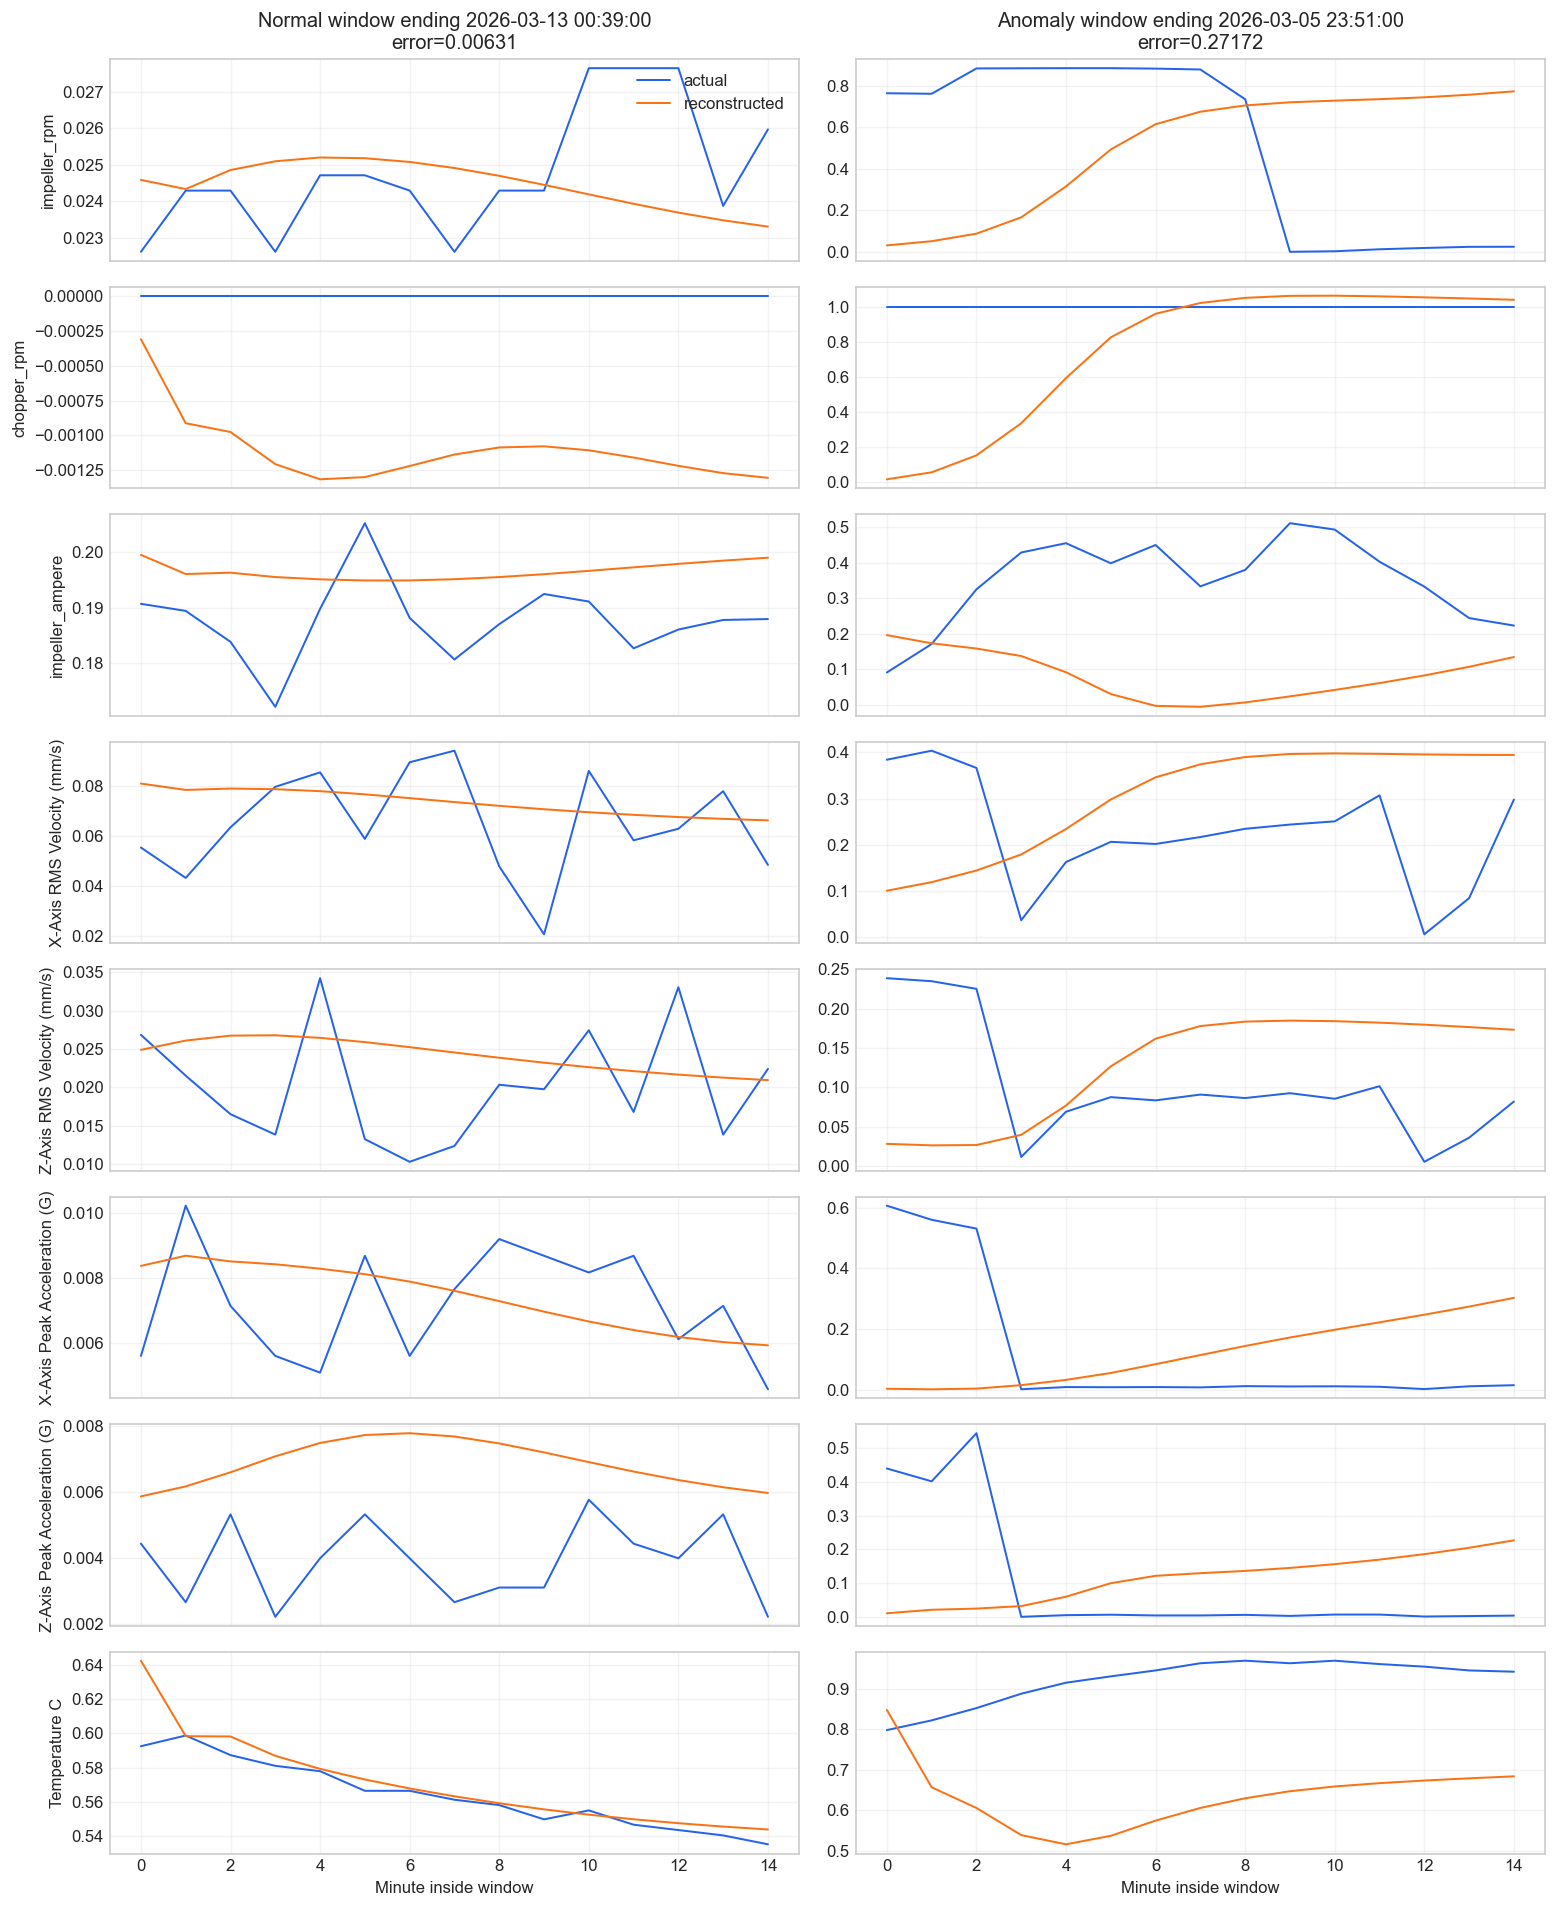

In [11]:
def select_example(split_name: str, choose_anomaly: bool) -> pd.Series | None:
    subset = windows_metadata[windows_metadata["split"].eq(split_name)].copy()
    subset = subset[subset["is_anomaly"]] if choose_anomaly else subset[~subset["is_anomaly"]]
    if subset.empty:
        return None
    if choose_anomaly:
        return subset.sort_values("reconstruction_error", ascending=False).iloc[0]
    return subset.sort_values("reconstruction_error", ascending=True).iloc[0]


def reconstruct_window(row: pd.Series):
    raw_window = feature_values[int(row.grid_start_pos) : int(row.grid_end_pos) + 1]
    scaled_window = scaler.transform(raw_window.reshape(-1, len(CORE_FEATURES))).reshape(1, WINDOW_SIZE, len(CORE_FEATURES))
    reconstructed = model.predict(scaled_window, verbose=0)[0]
    return scaled_window[0], reconstructed


normal_row = select_example("test", choose_anomaly=False)
anomaly_row = select_example("test", choose_anomaly=True)
if anomaly_row is None:
    anomaly_row = select_example("validation", choose_anomaly=True)

examples = [("normal", normal_row), ("anomaly", anomaly_row)]
available_examples = [(label, row) for label, row in examples if row is not None]
if len(available_examples) < 2:
    print("Not enough normal/anomalous examples available for side-by-side plotting.")
else:
    fig, axes = plt.subplots(len(CORE_FEATURES), 2, figsize=(13, 2.0 * len(CORE_FEATURES)), sharex=True)
    for col_idx, (label, row) in enumerate(available_examples[:2]):
        actual, reconstructed = reconstruct_window(row)
        for feature_idx, feature in enumerate(CORE_FEATURES):
            axes[feature_idx, col_idx].plot(actual[:, feature_idx], label="actual", linewidth=1.2, color="#2563EB")
            axes[feature_idx, col_idx].plot(reconstructed[:, feature_idx], label="reconstructed", linewidth=1.2, color="#F97316")
            axes[feature_idx, col_idx].set_ylabel(feature if col_idx == 0 else "")
            axes[feature_idx, col_idx].grid(alpha=0.25)
        axes[0, col_idx].set_title(f"{label.title()} window ending {row.end_timestamp}\nerror={row.reconstruction_error:.5f}")
        axes[-1, col_idx].set_xlabel("Minute inside window")
    axes[0, 0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## 12. Export Artifacts And Metadata

The report notebook refreshes the same aligned artifacts used by the backend-facing rebuild: cleaned grid, valid-window metadata, train/validation/test tensors, model, scaler, threshold metadata, and a JSON metadata summary.


In [12]:
df_grid.reset_index().to_csv(CLEAN_GRID_PATH, index=False)
windows_metadata.to_csv(WINDOW_METADATA_PATH, index=False)
np.savez_compressed(
    WINDOW_TENSOR_PATH,
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    train_window_ids=windows_metadata.loc[windows_metadata["split"].eq("train"), "window_id"].to_numpy(),
    val_window_ids=windows_metadata.loc[windows_metadata["split"].eq("validation"), "window_id"].to_numpy(),
    test_window_ids=windows_metadata.loc[windows_metadata["split"].eq("test"), "window_id"].to_numpy(),
)

rebuild_metadata = {
    "raw_data_path": repo_relative(RAW_DATA_PATH),
    "clean_grid_path": repo_relative(CLEAN_GRID_PATH),
    "window_metadata_path": repo_relative(WINDOW_METADATA_PATH),
    "window_tensor_path": repo_relative(WINDOW_TENSOR_PATH),
    "model_path": repo_relative(MODEL_PATH),
    "scaler_path": repo_relative(SCALER_PATH),
    "threshold_path": repo_relative(THRESHOLD_PATH),
    "report_notebook_path": repo_relative(BASE_DIR / "SPMS_LSTM_Autoencoder_Experimental_Report.ipynb"),
    "features": CORE_FEATURES,
    "excluded_features": EXCLUDED_DUPLICATE_FEATURES,
    "window_size": WINDOW_SIZE,
    "interpolation_policy": f"Only complete NaN runs <= {MICRO_GAP_LIMIT} minutes are linearly interpolated; macro-gaps remain NaN.",
    "state_policy": {
        "absolute_offline": "impeller_rpm == 0 and impeller_ampere == 0",
        "active_running": f"impeller_rpm >= {rpm_active_floor:.6f} and impeller_ampere >= {amp_active_floor:.6f}",
        "chopper_policy": "reported as diagnostic; not used as a hard active-running filter in this rebuild because process-dependent chopper-off windows are common and a hard chopper filter leaves too few valid windows",
    },
    "split_dates": split_report.reset_index().astype(str).to_dict(orient="records"),
    "valid_window_count": int(len(windows_metadata)),
    "valid_window_count_before_split_embargo": int(windows_before_split_embargo),
    "windows_dropped_for_split_embargo": int(windows_dropped_for_split_embargo),
    "skipped_window_count": int(skipped_window_count),
    "skipped_window_reasons": {key: int(value) for key, value in skipped.items()},
    "process_crossing_windows_retained": int((~windows_metadata["same_process"]).sum()),
    "windows_with_chopper_zero": int(windows_with_chopper_zero),
    "threshold": threshold,
    "threshold_policy": "99th percentile of validation reconstruction MAE",
    "evaluation": evaluation_report.to_dict(orient="records"),
    "limitations": [
        "Unsupervised anomaly detection only.",
        "No confirmed failure-label precision or recall.",
        "No validated RUL output.",
        "Valid windows are much fewer than compressed active-row windows because macro-gaps and inactive periods are rejected.",
        "Chopper-off windows remain in this rebuild and must be reviewed with process experts before final production use.",
    ],
}
METADATA_PATH.write_text(json.dumps(rebuild_metadata, indent=2), encoding="utf-8")

print(f"Saved cleaned full-grid data: {repo_relative(CLEAN_GRID_PATH)}")
print(f"Saved valid-window metadata: {repo_relative(WINDOW_METADATA_PATH)}")
print(f"Saved window tensors: {repo_relative(WINDOW_TENSOR_PATH)}")
print(f"Saved rebuild metadata: {repo_relative(METADATA_PATH)}")


Saved cleaned full-grid data: Data/data/spms_cleaned_full_grid.csv
Saved valid-window metadata: Data/data/spms_valid_windows_metadata.csv
Saved window tensors: Data/data/spms_lstm_windows_rebuild.npz
Saved rebuild metadata: Data/export_models/spms_lstm_rebuild_metadata.json


## 13. Artifact Reload Smoke Test

The final cell reloads the exported model, scaler, threshold, tensor file, and JSON metadata to make sure the notebook did not only work in memory.


In [13]:
loaded_model = keras.models.load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_threshold = joblib.load(THRESHOLD_PATH)
loaded_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
loaded_tensors = np.load(WINDOW_TENSOR_PATH)

assert loaded_model.input_shape[1:] == (WINDOW_SIZE, len(CORE_FEATURES))
assert hasattr(loaded_scaler, "data_min_")
assert "threshold" in loaded_threshold
assert loaded_metadata["features"] == CORE_FEATURES
assert loaded_tensors["X_train"].shape[1:] == (WINDOW_SIZE, len(CORE_FEATURES))

print("Artifact reload smoke test passed.")


Artifact reload smoke test passed.


## Required Reporting Checklist

This checklist is required for SPMS ML changes. It records the shape, valid/skipped windows, split dates, threshold policy, and limitations directly from notebook variables.


In [14]:
split_dates_text = split_report.reset_index().astype(str).to_string(index=False)
display(Markdown(
    f"""
- Data shape: raw rows `{observed_rows:,}`, full-grid rows `{len(df_grid):,}`.
- Valid-window count: `{len(windows_metadata):,}` after split embargo; `{windows_before_split_embargo:,}` before split embargo.
- Skipped-window count: `{skipped_window_count:,}`.
- Train, validation, and test split dates:
```text
{split_dates_text}
```
- Anomaly threshold: `{threshold}`.
- Threshold policy: 99th percentile of validation reconstruction MAE.
- Process-crossing windows retained: `{int((~windows_metadata['same_process']).sum()):,}`.
- Evaluation type: unsupervised anomaly detection only.
- Known limitations: no confirmed failure-label precision or recall, no validated RUL output, and chopper-off windows still need process-expert review.
"""
))



- Data shape: raw rows `414,720`, full-grid rows `414,720`.
- Valid-window count: `4,963` after split embargo; `4,977` before split embargo.
- Skipped-window count: `409,729`.
- Train, validation, and test split dates:
```text
     split windows  first_window_start    first_window_end   last_window_start     last_window_end
     train    3483 2025-05-30 21:26:00 2025-05-30 21:40:00 2025-11-06 22:45:00 2025-11-06 22:59:00
validation     746 2025-11-07 22:32:00 2025-11-07 22:46:00 2026-02-20 14:45:00 2026-02-20 14:59:00
      test     734 2026-02-20 15:00:00 2026-02-20 15:14:00 2026-03-13 00:32:00 2026-03-13 00:46:00
```
- Anomaly threshold: `0.2241775095462799`.
- Threshold policy: 99th percentile of validation reconstruction MAE.
- Process-crossing windows retained: `0`.
- Evaluation type: unsupervised anomaly detection only.
- Known limitations: no confirmed failure-label precision or recall, no validated RUL output, and chopper-off windows still need process-expert review.
